In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import numpy as np

In [2]:
conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=DESKTOP-55JNORK\\SQLEXPRESS;"
    "Database=phonepe;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()
print("Connected Successfully!")

Connected Successfully!


## User Engagement and Growth Strategy

## Scenario

PhonePe wants to understand user engagement across different
states and identify regions with high registered users.

The analysis focuses on user registration and engagement
patterns to support growth strategies.

## Objective

- Identify states with the highest registered users.
- Compare user engagement across states.
- Understand the distribution of registered users.
- Identify important regions for user growth.

### load data

In [8]:
query = """
SELECT TOP 10 *
FROM map_user
"""

df_test = pd.read_sql(query, conn)

print(df_test)
print(df_test.columns)

              States  Years  Quarter                          Districts  \
0  Andaman & Nicobar   2018        1  north and middle andaman district   
1  Andaman & Nicobar   2018        1             south andaman district   
2  Andaman & Nicobar   2018        1                  nicobars district   
3  Andaman & Nicobar   2018        2  north and middle andaman district   
4  Andaman & Nicobar   2018        2             south andaman district   
5  Andaman & Nicobar   2018        2                  nicobars district   
6  Andaman & Nicobar   2018        3  north and middle andaman district   
7  Andaman & Nicobar   2018        3             south andaman district   
8  Andaman & Nicobar   2018        3                  nicobars district   
9  Andaman & Nicobar   2018        4  north and middle andaman district   

   RegisteredUser  AppOpens  
0             632         0  
1            5846         0  
2             262         0  
3             911         0  
4            8143       

C:\Users\Devendra\AppData\Local\Temp\ipykernel_23108\2783452650.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_test = pd.read_sql(query, conn)


# top states

C:\Users\Devendra\AppData\Local\Temp\ipykernel_23108\1602745286.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_users = pd.read_sql(query, conn)


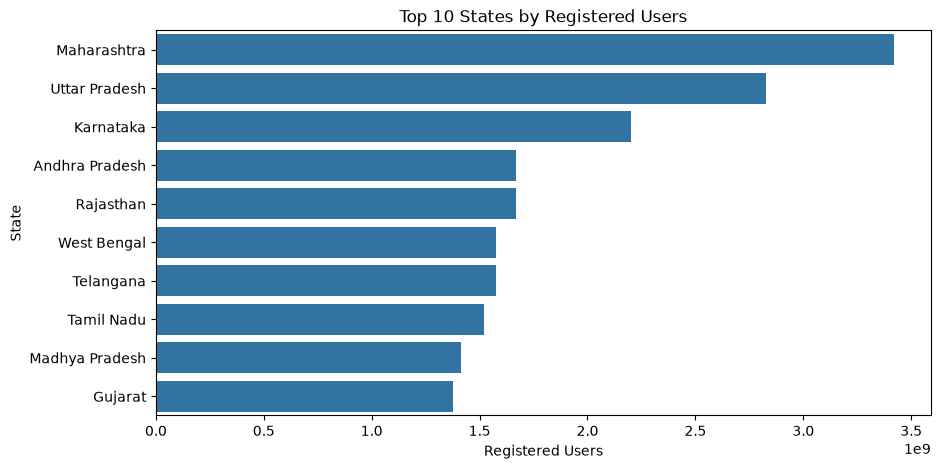

In [14]:
query = """
SELECT TOP 10
    States,
    SUM(RegisteredUser) AS Total_Users
FROM map_user
GROUP BY States
ORDER BY SUM(RegisteredUser) DESC
"""

df_users = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_users,
    x="Total_Users",
    y="States"
)

plt.title("Top 10 States by Registered Users")
plt.xlabel("Registered Users")
plt.ylabel("State")

plt.show()


##### “This chart shows the top 10 states based on the number of registered PhonePe users.”

## Top 10 States by App Opens

C:\Users\Devendra\AppData\Local\Temp\ipykernel_23108\3427655934.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_opens = pd.read_sql(query, conn)


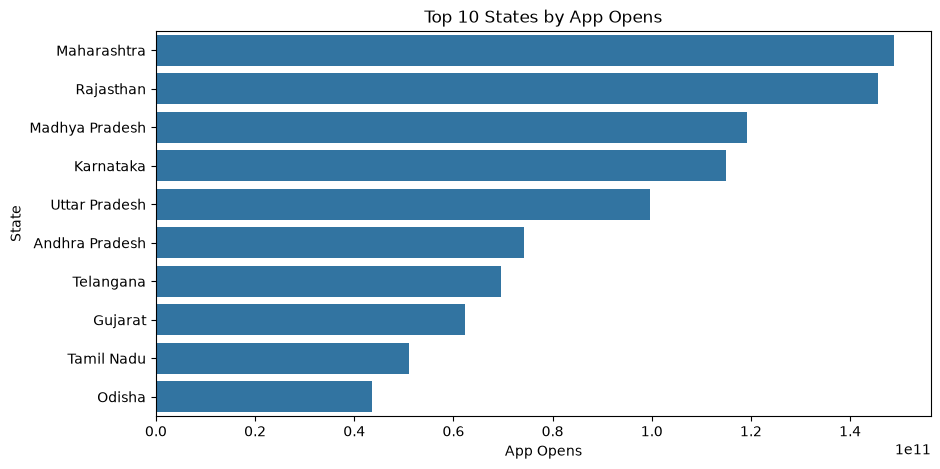

In [10]:
query = """
SELECT TOP 10
    States,
    SUM(AppOpens) AS Total_App_Opens
FROM map_user
GROUP BY States
ORDER BY Total_App_Opens DESC
"""

df_opens = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=df_opens, x="Total_App_Opens", y="States")

plt.title("Top 10 States by App Opens")
plt.xlabel("App Opens")
plt.ylabel("State")
plt.show()

##### “This chart shows the top 10 states based on the number of times users opened the PhonePe application.”
active users 

### User Engagement by State

C:\Users\Devendra\AppData\Local\Temp\ipykernel_23108\378194921.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_engage = pd.read_sql(query, conn)


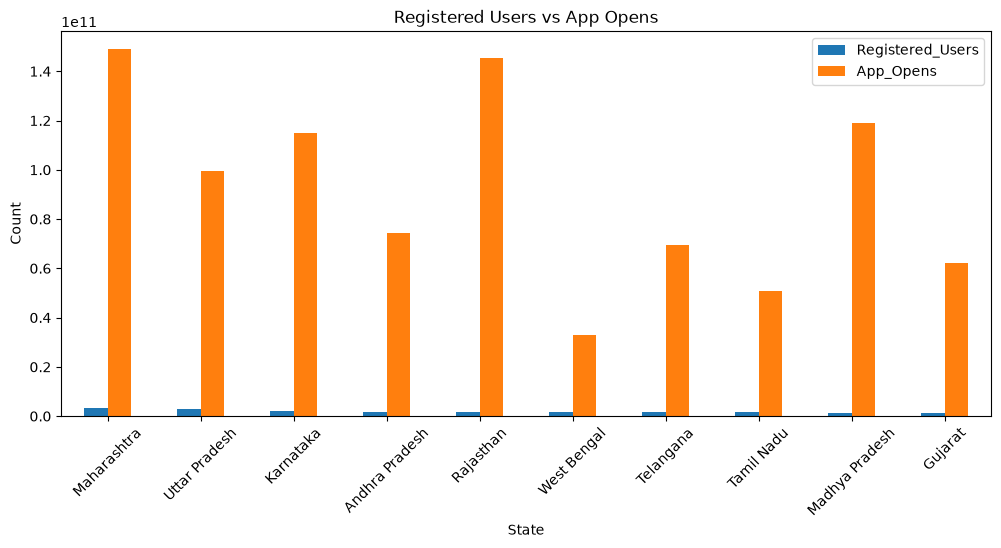

In [15]:
query = """
SELECT TOP 10
    States,
    SUM(RegisteredUser) AS Registered_Users,
    SUM(AppOpens) AS App_Opens
FROM map_user
GROUP BY States
ORDER BY SUM(RegisteredUser) DESC
"""

df_engage = pd.read_sql(query, conn)

df_engage.plot(
    x="States",
    y=["Registered_Users", "App_Opens"],
    kind="bar",
    figsize=(12,5)
)

plt.title("Registered Users vs App Opens")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

##### This chart compares the number of registered users with their app opens across states.”

##### “It helps us identify the difference between having users and actually engaging those users.”

#### recommendations:
1.Give offers and cashback to users who don't use the app often.

2.Focus more on states and districts where users are high but app opens are low.

3.Send useful notifications to bring users back to the app.

4.Improve marketing in areas where user engagement is low.


5.Focus on high-performing states to grow the business further.**

# Conclusion

“This analysis identifies the states with the highest number of users and shows how users are distributed across different device brands. PhonePe can use these insights to improve user engagement and focus growth strategies on important states and device segments.”